# Vision Transformer (ViT)

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/tensorchiefs/dl_course_2025/blob/master/notebooks/10_vit_explained.ipynb)


In this notebook you will use a pretrained Vision Transformer to predict a class
We won't train a model by ourself but rather use the power of freely available models which are pretrained by others on a large set of images


**Dataset**
- Pretrained model was trained on : Imagenet 14'197'122 images - 1000 Classes.

**Content**
1.   Load a pretrained VisionTransfomer model
2.   Predict the class of an image with the model (likelihoods)
3.   Inspect the Key components of the Architecture
4.   Inspect the Attentionmaps




 There is  a library which provides us with the necessary models
 py**T**orch **IM**age **M**odels (timm):

https://github.com/huggingface/pytorch-image-models
https://huggingface.co/docs/hub/timm

Imagenet: https://www.image-net.org/about.php

VisionTransformer: https://arxiv.org/abs/2010.11929

This notebook is adapted from https://colab.research.google.com/github/hirotomusiker/schwert_colab_data_storage/blob/master/notebook/Vision_Transformer_Tutorial.ipynb.

Check it out for more details!

-------

- some helper functions, check them out if needed, else skip to the next cell

In [1]:
# @title imports & helperfunctions
import os
import requests
import ast
import pandas as pd
import math

# PyTorch & timm
import numpy as np
import torch
import torch.nn.functional as F

!pip install torchinfo
from torchinfo import summary

import torchvision
import torchvision.transforms as T
from timm import create_model

# Displaying
from IPython.display import Image
from IPython.display import display as img_display
import ipywidgets as widgets
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
import matplotlib
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

import PIL
from tqdm import tqdm


def load_labels(verbose=0):
  url = 'https://raw.githubusercontent.com/tensorchiefs/dl_course_2024/main/notebooks/imagenet_labels.txt'
  response = requests.get(url)
  if response.status_code == 200:
      content = response.text
      try:
          # Use ast.literal_eval to safely parse the dictionary string
          imagenet_classes = ast.literal_eval(content)
          print("Dictionary loaded successfully!")
          if verbose ==1:
            for key in list(imagenet_classes.keys())[:5]:
                print(f"{key}: {imagenet_classes[key]}")
      except ValueError as e:
          print(f"Error parsing the content: {e}")
  display_options = [f"{index}: {name}" for index, name in imagenet_classes.items()]
  return display_options, imagenet_classes

display_options,imagenet_classes = load_labels(verbose=0)
class_dropdown = widgets.Dropdown(options=display_options,description='ImageNet Class:',)


# Optimized visualization function
def visualize_patches_optimized(i):
    fig, ax = plt.subplots(figsize=(6, 6))
    ax.set_title("Visualization of Patches")
    ax.set_xticks([])
    ax.set_yticks([])
    grid = np.zeros((224, 224, 3))
    for j, patch in enumerate(patches):
        x = j % 14
        y = j // 14
        grid[y*16:(y+1)*16, x*16:(x+1)*16] = patch
    ax.imshow(grid)
    x = (i % 14) * 16
    y = (i // 14) * 16
    rect = plt.Rectangle((x, y), 16, 16, linewidth=2, edgecolor='red', facecolor='none')
    ax.add_patch(rect)
    plt.show()


def generate_superimposed_image(img_array, heatmap, save_name=None):
    """overlay the heatmap on the image"""
    f, axs = plt.subplots(1, 1, figsize=(5, 5))
    ax1 = axs
    img_array = img_array / 255.0 if img_array.max() > 1 else img_array
    ax1.imshow(img_array, vmin=0, vmax=1)

    ax1.imshow(heatmap, cmap='jet', vmin=np.min(heatmap), vmax=np.max(heatmap), alpha=0.4)
    ax1.axis('off')
    axins = inset_axes(
        ax1,
        width="5%",  # width: 5% of parent_bbox width
        height="100%",  # height: 100% of parent_bbox height
        loc="lower left",
        bbox_to_anchor=(1.01, 0., 1, 1),
        bbox_transform=ax1.transAxes,
        borderpad=0,
    )
    plt.colorbar(
        matplotlib.cm.ScalarMappable(
            norm=matplotlib.colors.Normalize(vmin=heatmap.min(), vmax=heatmap.max(), clip=False),
            cmap="jet"
        ),
        cax=axins,
        label='',
        ticks=np.trunc(np.linspace(heatmap.min(), heatmap.max(), 5) * 100) / 100
    )
    if save_name is not None:
        plt.savefig(save_name, bbox_inches='tight', dpi=300)
    else:
        plt.show()


def patch_predict_image(x_range, y_range, img):

    """" occlude part of the image and predict the class of the image"""
    IMG_SIZE = (224, 224)
    transform_resize = T.Compose([
        T.Resize(IMG_SIZE),  # Resizes the image
    ])
    img_resized = transform_resize(img)
    img_resized = np.asarray(img_resized)
    x1, x2 = x_range
    y1, y2 = y_range
    img_array_patched = img_resized.copy()
    img_array_patched[y1:y2,x1:x2,:]=0
    img_normalized = ((img_array_patched - img_array_patched.min()) / (img_array_patched.max() - img_array_patched.min()) * 255).astype(np.uint8).squeeze()
    plt.imshow(img_normalized, vmin=0, vmax=255),plt.show()
    # return img_normalized
    print('ok')

    img_=PIL.Image.fromarray(img_normalized)
    img_tensor = preprocess_for_vit(img_).unsqueeze(0).to(device)

    z_scores=model(img_tensor)
    probabilities = F.softmax(z_scores, dim=-1)

    k = 10
    topk_probabilities, topk_indexes = torch.topk(probabilities, k=k, dim=-1)
    topk_probabilities=topk_probabilities.detach().cpu().numpy().squeeze().tolist()
    topk_indexes=topk_indexes.detach().cpu().numpy().squeeze().tolist()
    data= pd.DataFrame({"Rank": list(range(1, k + 1)),"Class Index": topk_indexes,"Probability": topk_probabilities,"Class Description": [imagenet_classes.get(idx, "Unknown class") for idx in topk_indexes]})
    print(data)

def visualize_patches_and_attention(i,j):
    """
    i: Patch index
    j: Block
    """
    # slected the encoder block
    attention_matrix = attention_heads[j]

    # Visualization of Attention Heatmaps
    fig = plt.figure(figsize=(8, rows * 2))
    fig.suptitle(f"Visualization of Attention Across All Heads for Patch {i+1}")

    # Display the small patch-reconstructed image in the top-left subplot
    ax = fig.add_subplot(rows, 4, 1)
    ax.imshow(grid)
    ax.axis("off")
    ax.set_title("Patch Image")

    # Highlight the selected patch in the grid
    patch_x = i % 14
    patch_y = i // 14
    rect = Rectangle((patch_x * 16, patch_y * 16), 16, 16, linewidth=2, edgecolor='red', facecolor='none')
    ax.add_patch(rect)

    # Loop through all attention heads
    for head_idx in range(num_heads):
        # extract the attention heatmap for the selected patch i+1 since first is the token..
        attn_heatmap = attention_matrix[head_idx, i+1, 1:].reshape((14, 14)).detach().cpu().numpy()
        ax = fig.add_subplot(rows, 4, head_idx + 2)
        ax.imshow(attn_heatmap, cmap='viridis')
        rect = Rectangle((patch_x - 0.5, patch_y - 0.5), 1, 1, linewidth=2, edgecolor='red', facecolor='none')
        ax.add_patch(rect)
        ax.axis("off")
        ax.set_title(f"Head {head_idx+1}")

    plt.tight_layout(rect=[0, 0, 1, 0.95])  # Adjust layout to fit title
    plt.show()

def visualize_cls_attention(block_j: int):
    """
    Plot only the CLS-token → patches attention for block `block_j`,
    automatically inferring the sqrt(grid) shape.
    """
    attn_mat = attention_heads[block_j]        # (H, N, N)
    H, N_queries, N_keys = attn_mat.shape

    # detect whether there's a [CLS] token in the keys dimension
    # if there is, we drop index 0; otherwise we take all keys
    has_cls = (N_keys == len(patches) + 1)
    start = 1 if has_cls else 0

    # how many patch-keys remain?
    num_patches = N_keys - start
    side = int(math.isqrt(num_patches))
    if side * side != num_patches:
        raise RuntimeError(f"Cannot reshape {num_patches} tokens into a square grid")

    # set up subplot grid for H heads
    cols = min(4, H)
    rows = (H + cols - 1) // cols

    fig, axes = plt.subplots(rows, cols, figsize=(4*cols, 4*rows))
    fig.suptitle(f"Class-Token → Patch Attention (Block {block_j})", fontsize=16)

    axes = axes.flatten()
    for head_idx in range(H):
        ax = axes[head_idx]
        # take the CLS query (row 0) and the patch-keys
        heat = attn_mat[head_idx, 0, start : ].reshape(side, side)
        heat = heat.detach().cpu().numpy()
        ax.imshow(heat, cmap="viridis", interpolation="nearest")
        ax.axis("off")
        ax.set_title(f"Head {head_idx+1}")

    # turn off any unused subplots
    for ax in axes[H:]:
        ax.axis("off")

    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()

def calculate_occ_stride(quadratic_size=224):
  occ_pairs=[]
  for occ_size in range(1,quadratic_size):
    for occ_stride in range(1,quadratic_size):
      if occ_stride >= occ_size:
        continue
      if (quadratic_size -occ_size)%occ_stride ==0:
        occ_pairs.append((occ_size,occ_stride))
  occ_pairs=[f'occlusion: {item[0]}, stride: {item[1]}'for item in occ_pairs ]
  return occ_pairs


def iter_occlusion(volume, size=4, stride = None):
    # volume: np array in shape 128, 128, 64, 1
    occlusion_center = np.full((size, size, 3), [0], np.float32)
    for y in range(0, volume.shape[0]-size+1, stride):
        for x in range(0, volume.shape[1]-size+1, stride):
            tmp = volume.copy()
            tmp[y:y + size, x:x + size, :] = occlusion_center
            yield x, y, tmp


def occlusion_heatmap(volume,correct_class=386,occlusion_size=4, occlusion_stride=None, clip_pred_hm=True):

    print('occluding...')
    if occlusion_stride is None:
        stride = occlusion_size
    elif occlusion_stride > occlusion_size:
        raise ValueError('stride must be smaller or equal size')


    if occlusion_stride == occlusion_size:
        if (not (volume.shape[0] / occlusion_size).is_integer() or
                not (volume.shape[1] / occlusion_size).is_integer()):

            raise ValueError('size does not work with this volume')
    elif occlusion_stride != occlusion_size:
        if (((volume.shape[0] - occlusion_size) % occlusion_stride) != 0 or
                ((volume.shape[1] - occlusion_size) % occlusion_stride) != 0):

            raise ValueError('shape and size do not match')

    heatmap_prob_sum = np.zeros((volume.shape[0], volume.shape[1]), np.float32)
    heatmap_occ_n = np.zeros((volume.shape[0], volume.shape[1]), np.float32)
    total_steps = int(np.prod(((np.array(volume.shape[0:2]) - occlusion_size) / occlusion_stride) + 1))

    with tqdm(total=total_steps, desc="Calculating heatmap") as pbar:
        for n, (x, y, vol_float) in enumerate(iter_occlusion(volume, size=occlusion_size, stride=occlusion_stride)):
            X = vol_float.reshape(1, volume.shape[0], volume.shape[1], volume.shape[2])
            img_=PIL.Image.fromarray(X.squeeze())
            img_tensor = preprocess_for_vit(img_).unsqueeze(0).to(device)
            z_scores=model(img_tensor)
            probabilities = F.softmax(z_scores, dim=-1)
            heatmap_prob_sum[y:y + occlusion_size, x:x + occlusion_size] += probabilities[0][correct_class].item()
            heatmap_occ_n[y:y + occlusion_size, x:x + occlusion_size] += 1
            pbar.update(1)
        print("calculating heatmap...")

    heatmap = heatmap_prob_sum / heatmap_occ_n

    if clip_pred_hm:
        img_tensor = preprocess_for_vit(img).unsqueeze(0).to(device)
        z_scores=model(img_tensor)
        probabilities = F.softmax(z_scores, dim=-1)
        cut_off =probabilities[0][correct_class].item()
        heatmap = np.abs(np.minimum(heatmap - cut_off, 0))
    plt.title(f"stride {occlusion_stride}, size {occlusion_size} class {correct_class}")
    plt.imshow(heatmap, cmap='viridis')
    return heatmap

Dictionary loaded successfully!


lets choose the african elephant nr 386 from the dataset
below you can inspect the differnet classes in imagenet 1k

In [3]:
display(class_dropdown)

Dropdown(description='ImageNet Class:', index=386, options=('0: tench, Tinca tinca', '1: goldfish, Carassius a…

- load an image and resize it

Original size: (2592, 3888)
Resized size: (224, 224)


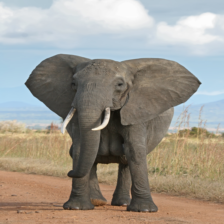

In [4]:
# Image URL
image_url = "https://raw.githubusercontent.com/tensorchiefs/dl_course_2024/main/notebooks/African_Bush_Elephant.jpg"

# Fetch the image
img = PIL.Image.open(requests.get(image_url, stream=True).raw)
print("Original size:", img.size)
IMG_SIZE = (224, 224)
transform = T.Compose([
    T.Resize(IMG_SIZE),  # Resizes the image
])
img_resized = transform(img)
print("Resized size:", img_resized.size)
img_resized

- cut the image up into patches

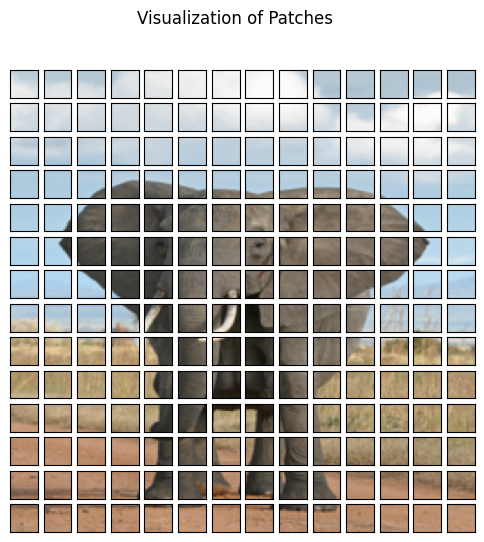

In [5]:
fig = plt.figure(figsize=(6, 6))
fig.suptitle("Visualization of Patches")
img_resized = np.asarray(img_resized)
for i in range(0, 196):
    x = i % 14
    y = i // 14
    patch = img_resized[y*16:(y+1)*16, x*16:(x+1)*16]
    ax = fig.add_subplot(14, 14, i+1)
    ax.axes.get_xaxis().set_visible(False)
    ax.axes.get_yaxis().set_visible(False)
    ax.imshow(patch)

<img src="https://raw.githubusercontent.com/tensorchiefs/dl_keras3/refs/heads/main/images/vit_overview.png" alt="Sample Image" width="1800">

- load the transformer model

In [6]:
model_name = "vit_base_patch16_224"
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print("device = ", device)
model = create_model(model_name, pretrained=True).to(device)
print("Model Pretrained Configuration: " )
model.default_cfg

device =  cpu


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

Model Pretrained Configuration: 


{'url': '',
 'hf_hub_id': 'timm/vit_base_patch16_224.augreg2_in21k_ft_in1k',
 'architecture': 'vit_base_patch16_224',
 'tag': 'augreg2_in21k_ft_in1k',
 'custom_load': False,
 'input_size': (3, 224, 224),
 'fixed_input_size': True,
 'interpolation': 'bicubic',
 'crop_pct': 0.9,
 'crop_mode': 'center',
 'mean': (0.5, 0.5, 0.5),
 'std': (0.5, 0.5, 0.5),
 'num_classes': 1000,
 'pool_size': None,
 'first_conv': 'patch_embed.proj',
 'classifier': 'head',
 'license': 'apache-2.0'}

- summary -> check out the parameters

In [7]:
summary(model)

Layer (type:depth-idx)                   Param #
VisionTransformer                        152,064
├─PatchEmbed: 1-1                        --
│    └─Conv2d: 2-1                       590,592
│    └─Identity: 2-2                     --
├─Dropout: 1-2                           --
├─Identity: 1-3                          --
├─Identity: 1-4                          --
├─Sequential: 1-5                        --
│    └─Block: 2-3                        --
│    │    └─LayerNorm: 3-1               1,536
│    │    └─Attention: 3-2               2,362,368
│    │    └─Identity: 3-3                --
│    │    └─Identity: 3-4                --
│    │    └─LayerNorm: 3-5               1,536
│    │    └─Mlp: 3-6                     4,722,432
│    │    └─Identity: 3-7                --
│    │    └─Identity: 3-8                --
│    └─Block: 2-4                        --
│    │    └─LayerNorm: 3-9               1,536
│    │    └─Attention: 3-10              2,362,368
│    │    └─Identity: 3-11     

### lets make a prediciton for the elephant image we've put in

- we get the likelihoods for each of the classes

In [8]:
# From the configuration, we can see that the model expects 224x224 and nomralized images mean 0.5 and std 0.5
IMG_SIZE = (224, 224)
NORMALIZE_MEAN = (0.5, 0.5, 0.5)
NORMALIZE_STD = (0.5, 0.5, 0.5)
transforms_vit = [T.Resize(IMG_SIZE),T.ToTensor(),T.Normalize(NORMALIZE_MEAN, NORMALIZE_STD)]
preprocess_for_vit = T.Compose(transforms_vit)
img_tensor = preprocess_for_vit(img).unsqueeze(0).to(device)

# Inference with the model
z_scores=model(img_tensor)
probabilities = F.softmax(z_scores, dim=-1)



<img src="https://raw.githubusercontent.com/tensorchiefs/dl_keras3/refs/heads/main/images/encoder_overview.png" alt="Sample Image" width="1500">


check out the probabilites for the classes does it make sense?

In [9]:
k = 10
topk_probabilities, topk_indexes = torch.topk(probabilities, k=k, dim=-1)
topk_probabilities=topk_probabilities.detach().cpu().numpy().squeeze().tolist()
topk_indexes=topk_indexes.detach().cpu().numpy().squeeze().tolist()

data= pd.DataFrame({"Rank": list(range(1, k + 1)),"Class Index": topk_indexes,"Probability": topk_probabilities,"Class Description": [imagenet_classes.get(idx, "Unknown class") for idx in topk_indexes]})
data.head(10)


,Rank,Class Index,Probability,Class Description
0,1,386,0.422193,"African elephant, Loxodonta africana"
1,2,101,0.400067,tusker
2,3,385,0.010720,"Indian elephant, Elephas maximus"
3,4,976,0.001569,"promontory, headland, head, foreland"
4,5,975,0.001348,"lakeside, lakeshore"
5,6,977,0.001244,"sandbar, sand bar"
6,7,979,0.001198,"valley, vale"
7,8,525,0.000858,"dam, dike, dyke"
8,9,974,0.000810,geyser
9,10,970,0.000749,alp


lets check out the positional encodings of the model

-> we can see that somehow the model was able to learn a vector which encodes the position of the patch in the image

Image tensor:  torch.Size([1, 3, 224, 224])
Patch embeddings:  torch.Size([1, 196, 768])
torch.Size([1, 197, 768])


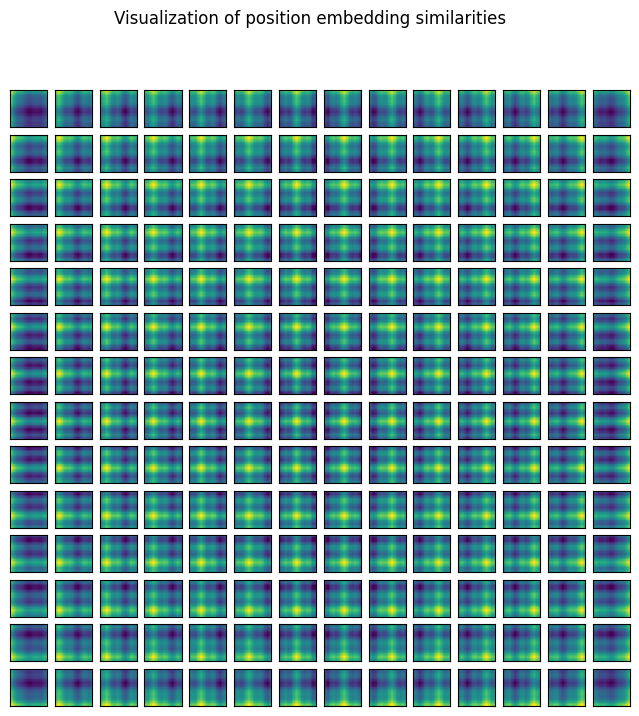

In [10]:

patches = model.patch_embed(img_tensor)  # patch embedding convolution
print("Image tensor: ", img_tensor.shape)
print("Patch embeddings: ", patches.shape)
pos_embed = model.pos_embed
print(pos_embed.shape)

transformer_input = torch.cat((model.cls_token, patches), dim=1) + pos_embed

# Visualize position embedding similarities.
# One cell shows cos similarity between an embedding and all the other embeddings.
cos = torch.nn.CosineSimilarity(dim=1, eps=1e-6)
fig = plt.figure(figsize=(8, 8))
fig.suptitle("Visualization of position embedding similarities")
for i in range(1, pos_embed.shape[1]):
    sim = F.cosine_similarity(pos_embed[0, i:i+1], pos_embed[0, 1:], dim=1)
    sim = sim.reshape((14, 14)).detach().cpu().numpy()
    ax = fig.add_subplot(14, 14, i)
    ax.axes.get_xaxis().set_visible(False)
    ax.axes.get_yaxis().set_visible(False)
    ax.imshow(sim)

## Visualize attention

In this model we have 12 Blocks with each 12 Attention Heads (MultiHeadSelf attention).

Each of these Heads has 14  Key and  14 Query Vectors for the patches aswell as 1 Key and 1 Value  Class Vector

-> go through the blocks and see what the indivuidal patch embeddings attend to:

In [11]:

# Preload the attention matrices for all blocks and heads
attention_heads=[]
for block_j in range(12):
    attention = model.blocks[block_j].attn
    transformer_input_expanded = attention.qkv(transformer_input)[0]
    qkv = transformer_input_expanded.reshape(197, 3, 12, 64)  # (N=197, (qkv), H=12, D/H=64)
    q = qkv[:, 0].permute(1, 0, 2)  # (H=12, N=197, D/H=64)
    k = qkv[:, 1].permute(1, 0, 2)  # (H=12, N=197, D/H=64)
    kT = k.permute(0, 2, 1)  # (H=12, D/H=64, N=197)
    attention_matrix = q @ kT
    attention_heads.append(attention_matrix)


# Create patchgrid for visualization of the orig image
img_resized_Sc = np.clip(img_resized, 0, 255) / 255.0  # Normalize to [0, 1]
patches = []
for j in range(196):
    x = j % 14
    y = j // 14
    patches.append(img_resized_Sc[y * 16:(y + 1) * 16, x * 16:(x + 1) * 16])
num_heads = attention_matrix.shape[0]  # Number of attention heads
rows = (num_heads + 1) // 4 + 1  # Calculate number of rows for subplot layout
# Create a grid to reconstruct the image from patches
grid = np.zeros((224, 224, 3))
for j, patch in enumerate(patches):
    x = j % 14
    y = j // 14
    grid[y * 16:(y + 1) * 16, x * 16:(x + 1) * 16] = patch

# Create an interactive slider to select the patch index
patch = widgets.IntSlider(value=0, min=0, max=195, step=1, description="Patch nr")
block = widgets.IntSlider(value=0, min=0, max=len(attention_heads)-1, step=1, description="Block nr")
# Create an interactive plot
interactive_plot = widgets.interactive(visualize_patches_and_attention, i=patch,j=block)
display(interactive_plot);

interactive(children=(IntSlider(value=0, description='Patch nr', max=195), IntSlider(value=0, description='Blo…

Before we only visualized the attention of the query and the keys withouth the classification token:

lets look at the classification tokens attentin in every block for every head:

In [12]:
# interactive block selector
block_slider = widgets.IntSlider(
    value=0,
    min=0,
    max=len(attention_heads)-1,
    step=1,
    description="Block"
)
interactive_plot = widgets.interactive(visualize_cls_attention, block_j=block_slider)
display(interactive_plot);

interactive(children=(IntSlider(value=0, description='Block', max=11), Output()), _dom_classes=('widget-intera…